In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    log_loss, brier_score_loss
)

RANDOM_STATE = 42
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pd.set_option("display.precision", 4)

In [28]:
import warnings

# Hide only sklearn's transition warnings (keeps other important warnings visible)
warnings.filterwarnings(
    "ignore",
    message=".*'penalty' was deprecated.*",
    category=FutureWarning,
    module=r"sklearn\.linear_model\._logistic"
)

warnings.filterwarnings(
    "ignore",
    message=".*Setting penalty=None will ignore the C and l1_ratio parameters.*",
    category=UserWarning,
    module=r"sklearn\.linear_model\._logistic"
)

In [42]:
def quick_data_overview(X, y, name="dataset"):
    X_type = type(X).__name__
    n, d = X.shape
    classes, counts = np.unique(y, return_counts=True)

    print(f"\n=== {name.upper()} OVERVIEW ===")
    print(f"X type: {X_type}")
    print(f"X shape: {X.shape}  (#samples, #features)")
    print(f"#classes: {len(classes)}")
    dfc = pd.DataFrame({"class": classes.astype(int), "count": counts.astype(int)})
    display(dfc)

def make_lr_l2(C=1.0, max_iter=2000):
    return LogisticRegression(
        solver="saga",
        penalty="elasticnet",
        l1_ratio=0.0,   # pure L2
        C=C,
        max_iter=max_iter
    )

def make_lr_l1(C=1.0, max_iter=5000):
    return LogisticRegression(
        solver="saga",
        penalty="elasticnet",
        l1_ratio=1.0,   # pure L1
        C=C,
        max_iter=max_iter
    )
    
def _predict_proba_or_fail(model, X):
    if not hasattr(model, "predict_proba"):
        raise ValueError("Model has no predict_proba(); cannot compute ROC/PR/logloss/brier.")
    return model.predict_proba(X)

def plot_confusion(y_true, y_pred, title, labels=None):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(values_format="d") #Creates a heatmap-style grid
    plt.title(title)
    plt.show()

def eval_binary(model, X_train, X_test, y_train, y_test, name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    proba = _predict_proba_or_fail(model, X_test)
    y_prob = proba[:, 1]  # P(y=1)

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", pos_label=1)
    auc = roc_auc_score(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ll = log_loss(y_test, proba, labels=[0, 1])
    brier = brier_score_loss(y_test, y_prob)

    print(f"\n===== {name} (Binary) =====")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}   Recall: {rec:.4f}   F1: {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}   PR-AUC(AP): {ap:.4f}")
    print(f"LogLoss:   {ll:.4f}   Brier: {brier:.4f}   (lower is better for both)")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=4))

    plot_confusion(y_test, y_pred, title=f"Confusion Matrix — {name}", labels=[0, 1])

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=1)
    plt.figure()
    plt.plot(fpr, tpr, marker="o", label=f"{name} (AUC={auc:.3f})") #.3f rounds to 3 decimal places, 0.9995 --> 1.000 (as seen on plot)
    plt.plot([0, 1], [0, 1], linestyle="--") # diagonal line
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {name}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # PR
    precision, recall, _ = precision_recall_curve(y_test, y_prob, pos_label=1)
    pos_rate = y_test.mean()
    
    plt.figure()
    plt.plot(recall, precision, label="Model")
    plt.hlines(pos_rate, 0, 1, linestyles='--', label="Baseline") #baseline for reference
    
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC_AUC": auc,
        "PR_AUC_AP": ap,
        "LogLoss": ll,
        "Brier": brier
    }

def eval_multiclass(model, X_train, X_test, y_train, y_test, name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    proba = _predict_proba_or_fail(model, X_test)

    acc = accuracy_score(y_test, y_pred)
    pm, rm, f1m, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0) #for precision and recall, when division by 0 occurs, return 0
    pw, rw, f1w, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)
    ll = log_loss(y_test, proba)

    # Multiclass ROC-AUC via OvR
    auc_ovr_macro = roc_auc_score(y_test, proba, multi_class="ovr", average="macro")
    auc_ovr_weighted = roc_auc_score(y_test, proba, multi_class="ovr", average="weighted")

    print(f"\n===== {name} (Multiclass) =====")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro   P/R/F1: {pm:.4f} / {rm:.4f} / {f1m:.4f}")
    print(f"WeightedP/R/F1: {pw:.4f} / {rw:.4f} / {f1w:.4f}")
    print(f"LogLoss: {ll:.4f} (lower is better)")
    print(f"ROC-AUC OvR (macro): {auc_ovr_macro:.4f}   OvR (weighted): {auc_ovr_weighted:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=4)) # precision to 4 digits after decimal point

    plot_confusion(y_test, y_pred, title=f"Confusion Matrix — {name}")

    return {
        "Model": name,
        "Accuracy": acc,
        "Macro_F1": f1m,
        "Weighted_F1": f1w,
        "LogLoss": ll,
        "ROC_AUC_OVR_macro": auc_ovr_macro,
        "ROC_AUC_OVR_weighted": auc_ovr_weighted
    }

def cv_table(models, X, y, scoring, cv=cv5):
    rows = []
    for name, model in models:
        scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        row = {"Model": name}
        for key in scoring.keys():
            vals = scores[f"test_{key}"]
            row[f"{key}_mean"] = float(vals.mean())
            row[f"{key}_std"] = float(vals.std())
        rows.append(row)
    return pd.DataFrame(rows)

def plot_learning_curve(model, X, y, title, scoring="accuracy", cv=cv5):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=cv,
        train_sizes=np.linspace(0.1, 1.0, 6),
        scoring=scoring,
        n_jobs=-1,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.figure(figsize=(7, 5))
    plt.plot(train_sizes, train_mean, marker="o", label="Training score")
    plt.plot(train_sizes, val_mean, marker="o", label="Cross-val score")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
    plt.xlabel("Number of training examples")
    plt.ylabel(f"Score ({scoring})")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [43]:
#BINARY DEMO (Digits: 3 vs 8)

In [44]:
#Load binary dataset + overview
digits = load_digits()
X = digits.data
y = digits.target

# binary: 3 vs 8 (more interesting than 0 vs 1)
mask = np.isin(y, [3, 8])
Xb = X[mask]
yb = y[mask]
yb = (yb == 8).astype(int)  # positive class = 8

quick_data_overview(Xb, yb, name="Digits (3 vs 8) Binary")

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb, test_size=0.25, stratify=yb, random_state=RANDOM_STATE
)


=== DIGITS (3 VS 8) BINARY OVERVIEW ===
X type: ndarray
X shape: (357, 64)  (#samples, #features)
#classes: 2


,class,count
0,0,183
1,1,174



===== LR L2 (lbfgs, C=1) (Binary) =====
Accuracy:  0.9889
Precision: 0.9778   Recall: 1.0000   F1: 0.9888
ROC-AUC:   1.0000   PR-AUC(AP): 1.0000
LogLoss:   0.0193   Brier: 0.0059   (lower is better for both)

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9783    0.9890        46
           1     0.9778    1.0000    0.9888        44

    accuracy                         0.9889        90
   macro avg     0.9889    0.9891    0.9889        90
weighted avg     0.9891    0.9889    0.9889        90



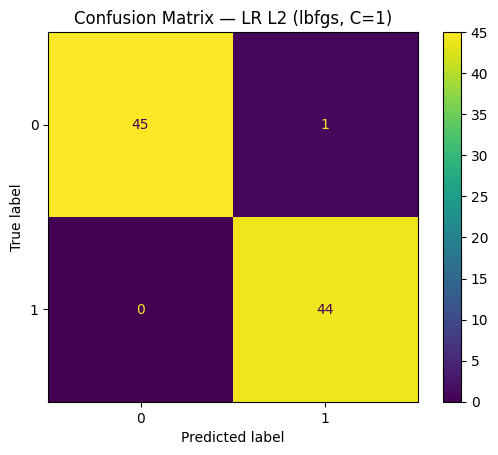

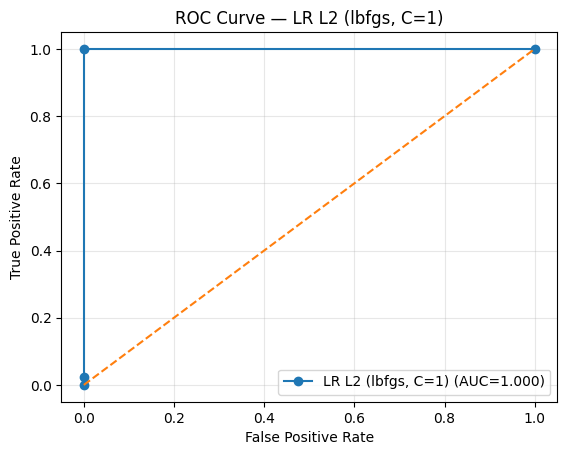

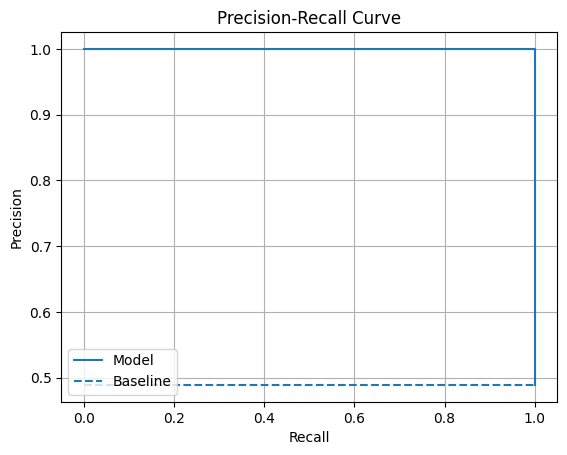


===== LR L1 (saga, C=1) (Binary) =====
Accuracy:  0.9778
Precision: 0.9565   Recall: 1.0000   F1: 0.9778
ROC-AUC:   0.9995   PR-AUC(AP): 0.9995
LogLoss:   0.0419   Brier: 0.0135   (lower is better for both)

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9565    0.9778        46
           1     0.9565    1.0000    0.9778        44

    accuracy                         0.9778        90
   macro avg     0.9783    0.9783    0.9778        90
weighted avg     0.9787    0.9778    0.9778        90



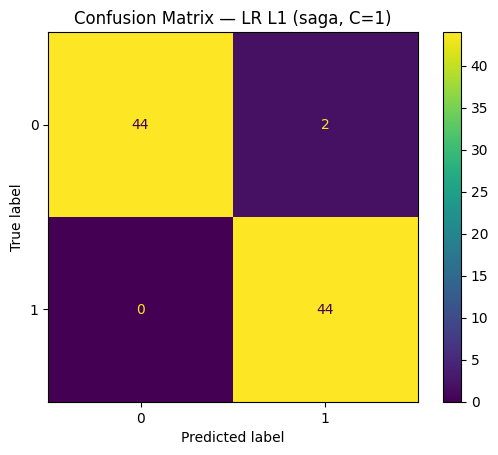

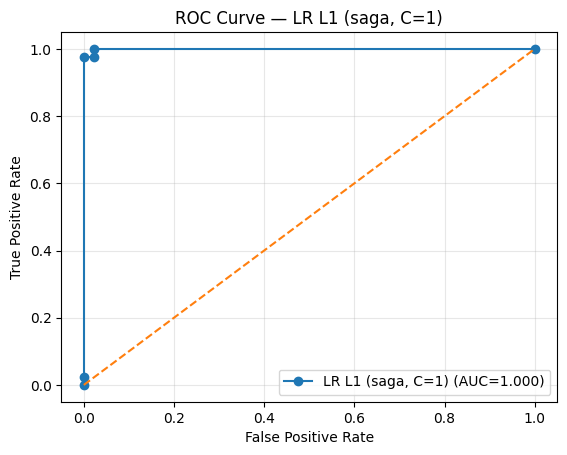

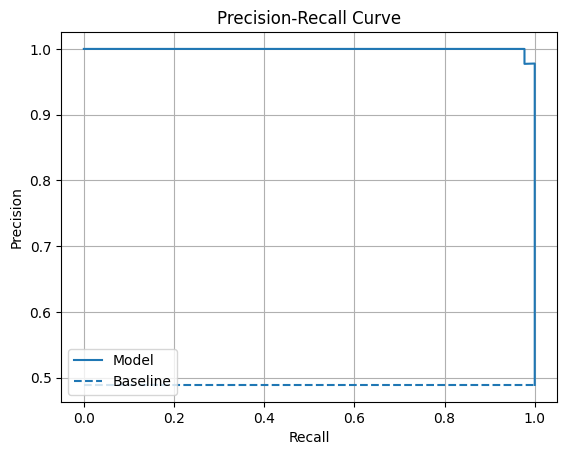

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC_AP,LogLoss,Brier
0,"LR L2 (lbfgs, C=1)",0.9889,0.9778,1.0,0.9888,1.0000,1.0000,0.0193,0.0059
1,"LR L1 (saga, C=1)",0.9778,0.9565,1.0,0.9778,0.9995,0.9995,0.0419,0.0135


In [45]:
binary_models = [
    ("LR L2 (lbfgs, C=1)", make_lr_l2(C=1.0)),
    ("LR L1 (saga, C=1)",  make_lr_l1(C=1.0)),
]

binary_results = []
for name, model in binary_models:
    binary_results.append(eval_binary(model, Xb_train, Xb_test, yb_train, yb_test, name=name))

display(pd.DataFrame(binary_results).sort_values("ROC_AUC", ascending=False))

In [46]:
#Binary CV table (mean ± std)
binary_scoring = {
    "acc": "accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "ap": "average_precision"
}

df_bin_cv = cv_table(binary_models, Xb, yb, scoring=binary_scoring, cv=cv5)
display(df_bin_cv)

,Model,acc_mean,acc_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,ap_mean,ap_std
0,"LR L2 (lbfgs, C=1)",0.9944,0.0069,0.9944,0.0069,1.0000,0.000,1.0000,0.000
1,"LR L1 (saga, C=1)",0.9944,0.0069,0.9944,0.0069,0.9995,0.001,0.9995,0.001


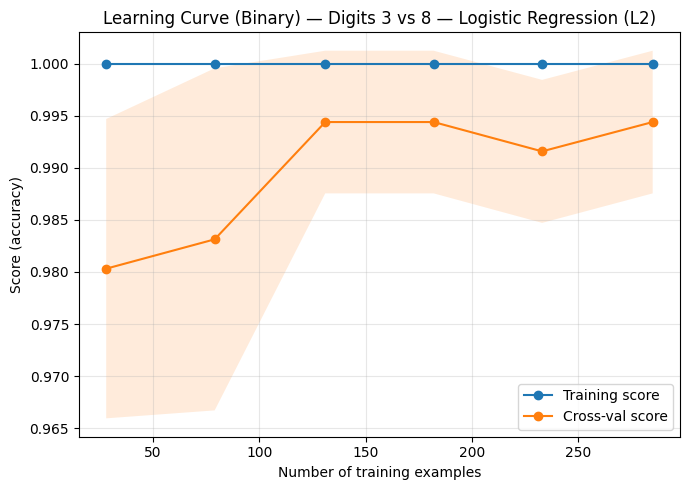

In [47]:
#Binary learning curve (pick one model)
plot_learning_curve(
    make_lr_l2(C=1.0),
    Xb, yb,
    title="Learning Curve (Binary) — Digits 3 vs 8 — Logistic Regression (L2)",
    scoring="accuracy"
)

In [48]:
#MULTICLASS DEMO (Digits: 0–9)

In [49]:
# Load multiclass dataset + overview
Xm = X
ym = y
quick_data_overview(Xm, ym, name="Digits (0–9) Multiclass")

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    Xm, ym, test_size=0.25, stratify=ym, random_state=RANDOM_STATE
)


=== DIGITS (0–9) MULTICLASS OVERVIEW ===
X type: ndarray
X shape: (1797, 64)  (#samples, #features)
#classes: 10


,class,count
0,0,178
1,1,182
2,2,177
3,3,183
4,4,181
5,5,182
6,6,181
7,7,179
8,8,174
9,9,180



===== Softmax L2  (Multiclass) =====
Accuracy: 0.9667
Macro   P/R/F1: 0.9668 / 0.9662 / 0.9663
WeightedP/R/F1: 0.9669 / 0.9667 / 0.9666
LogLoss: 0.1149 (lower is better)
ROC-AUC OvR (macro): 0.9989   OvR (weighted): 0.9989

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        45
           1     0.8958    0.9348    0.9149        46
           2     1.0000    0.9773    0.9885        44
           3     0.9787    1.0000    0.9892        46
           4     0.9574    1.0000    0.9783        45
           5     0.9783    0.9783    0.9783        46
           6     0.9778    0.9778    0.9778        45
           7     1.0000    0.9778    0.9888        45
           8     0.9024    0.8605    0.8810        43
           9     0.9773    0.9556    0.9663        45

    accuracy                         0.9667       450
   macro avg     0.9668    0.9662    0.9663       450
weighted avg     0.9669    0.9667    0.9666     

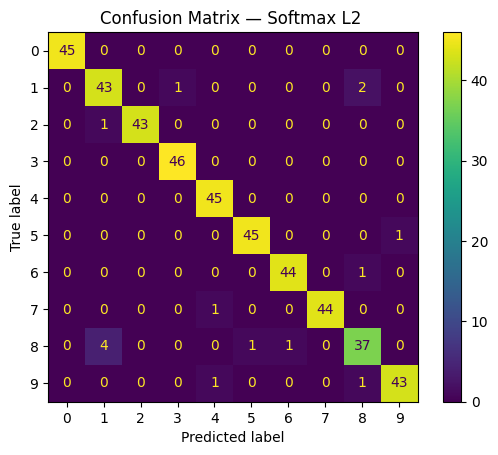


===== Softmax L1  (Multiclass) =====
Accuracy: 0.9556
Macro   P/R/F1: 0.9559 / 0.9551 / 0.9552
WeightedP/R/F1: 0.9563 / 0.9556 / 0.9556
LogLoss: 0.1237 (lower is better)
ROC-AUC OvR (macro): 0.9988   OvR (weighted): 0.9988

Classification report:
              precision    recall  f1-score   support

           0     0.9773    0.9556    0.9663        45
           1     0.8958    0.9348    0.9149        46
           2     0.9545    0.9545    0.9545        44
           3     0.9787    1.0000    0.9892        46
           4     0.9574    1.0000    0.9783        45
           5     1.0000    0.9783    0.9890        46
           6     0.9778    0.9778    0.9778        45
           7     0.9778    0.9778    0.9778        45
           8     0.8636    0.8837    0.8736        43
           9     0.9756    0.8889    0.9302        45

    accuracy                         0.9556       450
   macro avg     0.9559    0.9551    0.9552       450
weighted avg     0.9563    0.9556    0.9556     

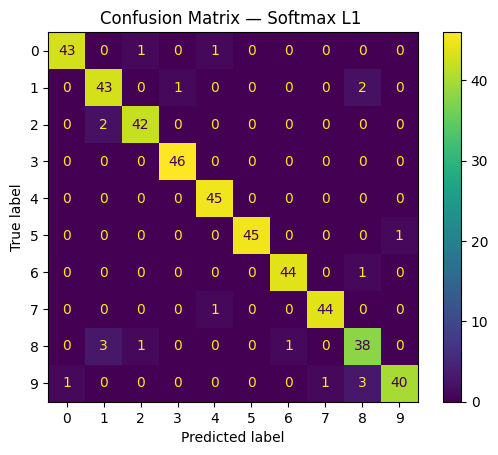

/Users/cen/tf-env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



===== OvR L2 (Multiclass) =====
Accuracy: 0.9622
Macro   P/R/F1: 0.9629 / 0.9619 / 0.9621
WeightedP/R/F1: 0.9631 / 0.9622 / 0.9623
LogLoss: 0.1350 (lower is better)
ROC-AUC OvR (macro): 0.9988   OvR (weighted): 0.9988

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9778    0.9888        45
           1     0.8776    0.9348    0.9053        46
           2     1.0000    1.0000    1.0000        44
           3     0.9787    1.0000    0.9892        46
           4     0.9574    1.0000    0.9783        45
           5     1.0000    0.9783    0.9890        46
           6     0.9773    0.9556    0.9663        45
           7     0.9778    0.9778    0.9778        45
           8     0.8837    0.8837    0.8837        43
           9     0.9762    0.9111    0.9425        45

    accuracy                         0.9622       450
   macro avg     0.9629    0.9619    0.9621       450
weighted avg     0.9631    0.9622    0.9623       450

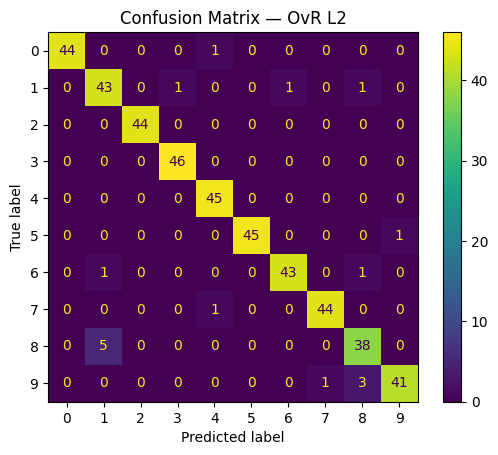


===== OvR L1 (Multiclass) =====
Accuracy: 0.9578
Macro   P/R/F1: 0.9588 / 0.9574 / 0.9578
WeightedP/R/F1: 0.9590 / 0.9578 / 0.9580
LogLoss: 0.1381 (lower is better)
ROC-AUC OvR (macro): 0.9987   OvR (weighted): 0.9987

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9778    0.9888        45
           1     0.8571    0.9130    0.8842        46
           2     1.0000    0.9545    0.9767        44
           3     0.9583    1.0000    0.9787        46
           4     0.9574    1.0000    0.9783        45
           5     1.0000    0.9783    0.9890        46
           6     0.9773    0.9556    0.9663        45
           7     0.9778    0.9778    0.9778        45
           8     0.8837    0.8837    0.8837        43
           9     0.9767    0.9333    0.9545        45

    accuracy                         0.9578       450
   macro avg     0.9588    0.9574    0.9578       450
weighted avg     0.9590    0.9578    0.9580       450

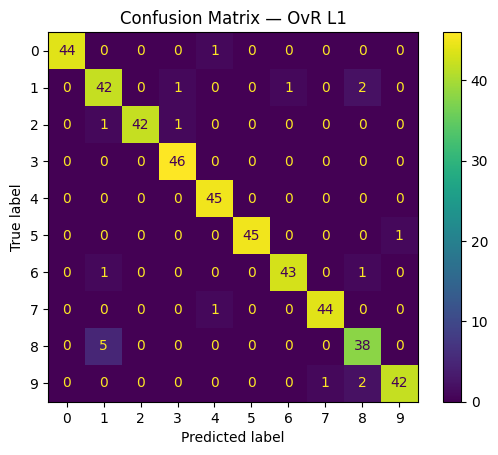

,Model,Accuracy,Macro_F1,Weighted_F1,LogLoss,ROC_AUC_OVR_macro,ROC_AUC_OVR_weighted
0,Softmax L2,0.9667,0.9663,0.9666,0.1149,0.9989,0.9989
2,OvR L2,0.9622,0.9621,0.9623,0.1350,0.9988,0.9988
3,OvR L1,0.9578,0.9578,0.9580,0.1381,0.9987,0.9987
1,Softmax L1,0.9556,0.9552,0.9556,0.1237,0.9988,0.9988


In [54]:
# Softmax (multinomial) vs One-vs-Rest + L2 vs L1
softmax_l2 = make_lr_l2(C=1.0)
softmax_l1 = make_lr_l1(C=1.0)

ovr_l2 = OneVsRestClassifier(make_lr_l2(C=1.0))  # OvR wrapper
ovr_l1 = OneVsRestClassifier(make_lr_l1(C=1.0))

mc_models = [
    ("Softmax L2 ", softmax_l2),
    ("Softmax L1 ", softmax_l1),
    ("OvR L2", ovr_l2),
    ("OvR L1", ovr_l1),
]

mc_results = []
for name, model in mc_models:
    mc_results.append(eval_multiclass(model, Xm_train, Xm_test, ym_train, ym_test, name=name))

display(pd.DataFrame(mc_results).sort_values("Accuracy", ascending=False))

In [51]:
mc_scoring = {
    "acc": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
    "neg_log_loss": "neg_log_loss"
}

df_mc_cv = cv_table(mc_models, Xm, ym, scoring=mc_scoring, cv=cv5)

# Make logloss easier to read: convert neg_log_loss -> log_loss
df_mc_cv["log_loss_mean"] = -df_mc_cv["neg_log_loss_mean"] #double negation put it back to original log_loss, the smaller the better
df_mc_cv["log_loss_std"] = df_mc_cv["neg_log_loss_std"]
df_mc_cv = df_mc_cv.drop(columns=["neg_log_loss_mean", "neg_log_loss_std"])

display(df_mc_cv)

/Users/cen/tf-env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/cen/tf-env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/cen/tf-env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/cen/tf-env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/cen/tf-env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/cen/tf-env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: Convergen

,Model,acc_mean,acc_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,log_loss_mean,log_loss_std
0,Softmax L2 (multinomial),0.9661,0.0037,0.9660,0.0036,0.9660,0.0037,0.1163,0.0169
1,Softmax L1 (multinomial),0.9622,0.0048,0.9621,0.0047,0.9621,0.0048,0.1158,0.0156
2,OvR L2,0.9616,0.0064,0.9617,0.0064,0.9617,0.0062,0.1780,0.0339
3,OvR L1,0.9638,0.0053,0.9638,0.0054,0.9639,0.0052,0.1646,0.0259


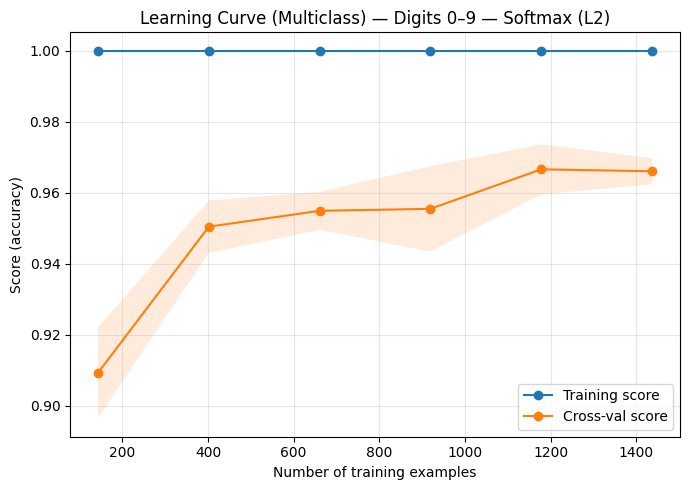

In [53]:
#Multiclass learning curve (pick one model)
plot_learning_curve(
    softmax_l2,
    Xm, ym,
    title="Learning Curve (Multiclass) — Digits 0–9 — Softmax (L2)",
    scoring="accuracy"
)